In [7]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Data preprocessing & model selection
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', message='.*penalty.*')
warnings.filterwarnings('ignore', message='.*use_label_encoder.*')

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
# Load dataset
df = pd.read_csv('Training_Dataset.csv')
print("Dataset shape:", df.shape)

# Display first 5 rows of the data
print("\nFirst 5 rows:")
display(df.head())

# Display dataset information
print("\nData types and null counts:")
print(df.info())

# Display statistical summary
print("\nStatistical summary:")
display(df.describe())

Dataset shape: (11055, 31)

First 5 rows:


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1



Data types and null counts:
<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor               

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Target distribution (Result):
Result
 1    6157
-1    4898
Name: count, dtype: int64


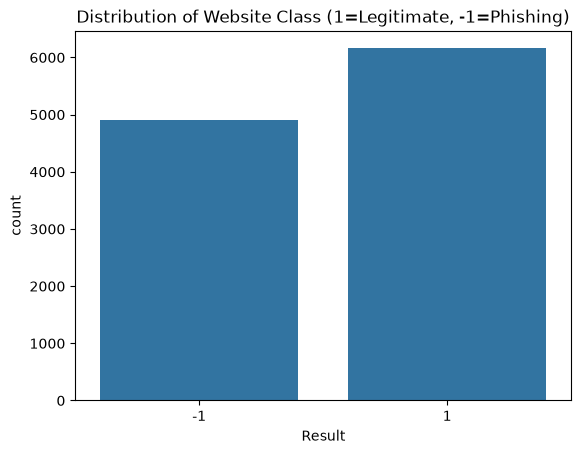


Missing values per column:
No missing values found.


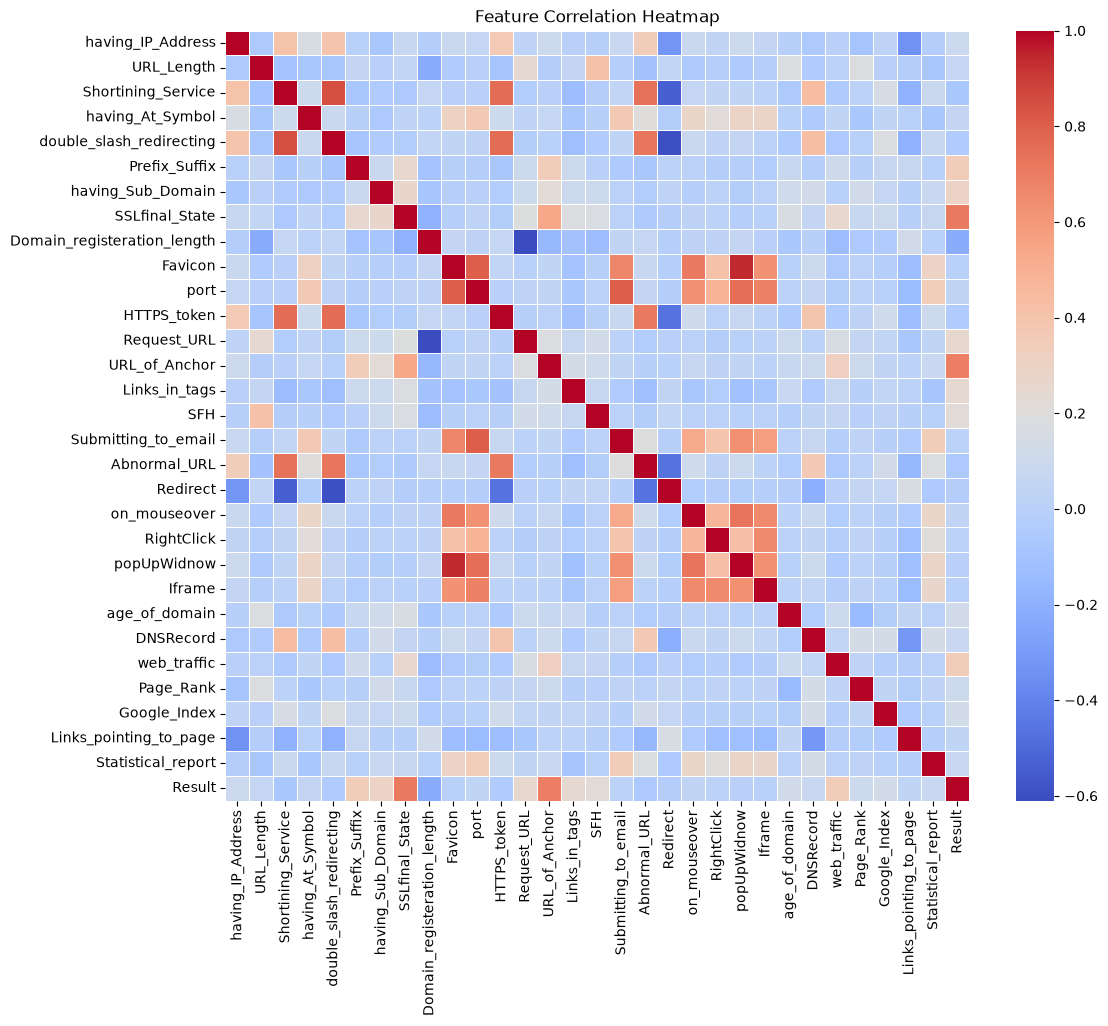

In [9]:
# Target distribution
print("Target distribution (Result):")
print(df['Result'].value_counts())

# Visualise target balance
sns.countplot(data=df, x='Result')
plt.title('Distribution of Website Class (1=Legitimate, -1=Phishing)')
plt.show()

# Check for missing values
missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing[missing > 0] if any(missing > 0) else "No missing values found.")

# Correlation heatmap 
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

## Model Sections

### Model 1 — Logistic Regression

X_train shape: (8844, 30)
X_test shape: (2211, 30)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Logistic Regression Params: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Accuracy: 0.9284269815244445

Logistic Regression Test Performance:
Accuracy : 0.9240
Precision: 0.9276
Recall   : 0.9394
F1-score : 0.9335

Classification Report:
               precision    recall  f1-score   support

    Phishing       0.92      0.90      0.91       956
  Legitimate       0.93      0.94      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      2211
weighted avg       0.92      0.92      0.92      2211



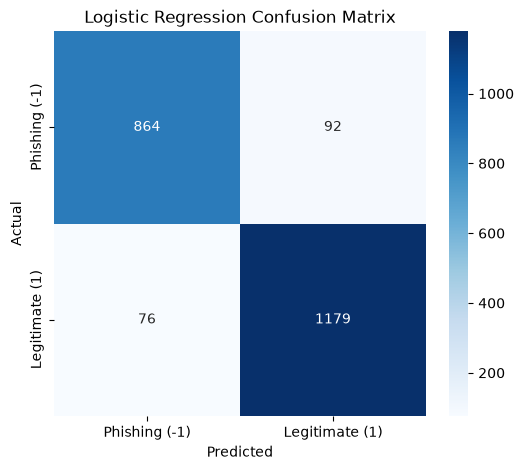

In [11]:
# Logistic Regression

#Separate data into X(Features the model uses to make a prediction) and Y(Target variable)
X = df.drop(['Result'], axis=1)
y = df['Result']

#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Base model
lr = LogisticRegression(max_iter=200)

# Hyperparameter grid
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100], # Regularization strength (smaller = stronger)
    'penalty': ['l1', 'l2'], # Regularization type
    'solver': ['liblinear', 'saga'] # Compatible solvers
}

# Grid search with 5-fold CV
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
print("Best Logistic Regression Params:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)

# Evaluation on test set
y_pred_lr = best_lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, pos_label=1)
rec_lr = recall_score(y_test, y_pred_lr, pos_label=1)
f1_lr = f1_score(y_test, y_pred_lr, pos_label=1)

print("\nLogistic Regression Test Performance:")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, target_names=['Phishing', 'Legitimate']))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Phishing (-1)', 'Legitimate (1)'],
            yticklabels=['Phishing (-1)', 'Legitimate (1)'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [17]:
# Feature selection for Logistic Regression (RFECV)

# Base Logistic Regression model used for feature selection
selector = LogisticRegression(max_iter=200, solver='liblinear')

# RFECV will recursively removes the least important feature, one at a time, until only 1 feature remains.
# Then it uses 5-fold cross-validation accuracy to determine the optimal number of features to select.
rfecv_lr = RFECV(
    estimator=selector, #Use Logistic Regression to evaluate feature importance
    step=1,              # Remove 1 feature at a time
    cv=5,                # 5-fold cross-validation
    scoring='accuracy',  #Compare feature subses using accuracy
    n_jobs=-1            #Use all available CPU cores
)

# Perform RFECV feature selection on the training data
rfecv_lr.fit(X_train, y_train)

# Selected features
selected_lr = X_train.columns[rfecv_lr.support_]
print("Optimal number of features (LR):", rfecv_lr.n_features_)
print("Selected features:", list(selected_lr))
print("Dropped features:", list(X_train.columns[~rfecv_lr.support_]))

# Transform data
X_train_lr_sel = X_train[selected_lr]
X_test_lr_sel = X_test[selected_lr]

# Retrain best model on selected features
grid_lr_sel = GridSearchCV(LogisticRegression(max_iter=200),
                           param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
grid_lr_sel.fit(X_train_lr_sel, y_train)
best_lr_sel = grid_lr_sel.best_estimator_

# Evaluate
y_pred_lr_sel = best_lr_sel.predict(X_test_lr_sel)
acc_lr_sel = accuracy_score(y_test, y_pred_lr_sel)
prec_lr_sel = precision_score(y_test, y_pred_lr_sel, pos_label=1)
rec_lr_sel = recall_score(y_test, y_pred_lr_sel, pos_label=1)
f1_lr_sel = f1_score(y_test, y_pred_lr_sel, pos_label=1)

print("\nLogistic Regression with RFECV Features:")
print(f"Accuracy : {acc_lr_sel:.4f}")
print(f"Precision: {prec_lr_sel:.4f}")
print(f"Recall   : {rec_lr_sel:.4f}")
print(f"F1-score : {f1_lr_sel:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_sel))

Optimal number of features (LR): 29
Selected features: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']
Dropped features: ['Domain_registeration_length']

Logistic Regression with RFECV Features:
Accuracy : 0.9240
Precision: 0.9269
Recall   : 0.9402
F1-score : 0.9335

Confusion Matrix:
[[ 863   93]
 [  75 1180]]


### Model 2 — Random Forest

Training set: (8844, 30)
Testing set: (2211, 30)

Baseline Random Forest
----------------------
Accuracy : 0.9742
Precision: 0.9696
Recall   : 0.9846
F1-score : 0.9770
Optimal number of features (RF): 24
Selected features: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Redirect', 'popUpWidnow', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']


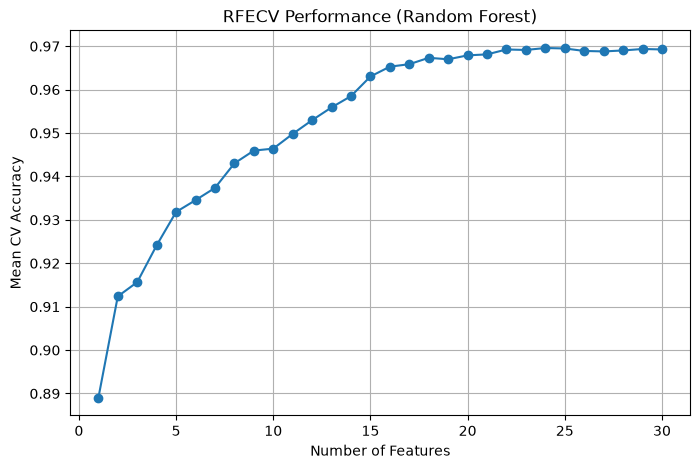


Random Forest (RFECV Selected Features):
Accuracy : 0.9747
Precision: 0.9711
Recall   : 0.9838
F1-score : 0.9774


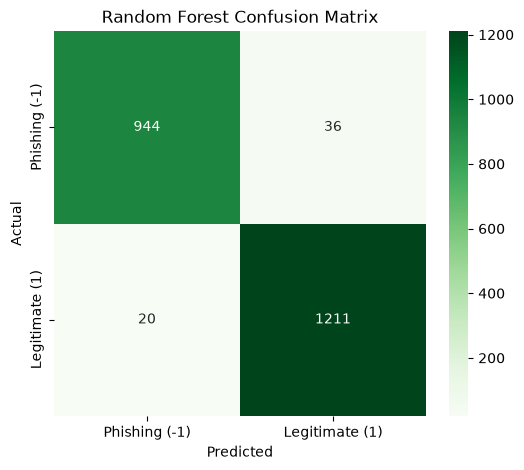

,Baseline Random Forest,RFECV Random Forest
Accuracy,0.9742,0.9747
Precision,0.9696,0.9711
Recall,0.9846,0.9838
F1-score,0.9770,0.9774


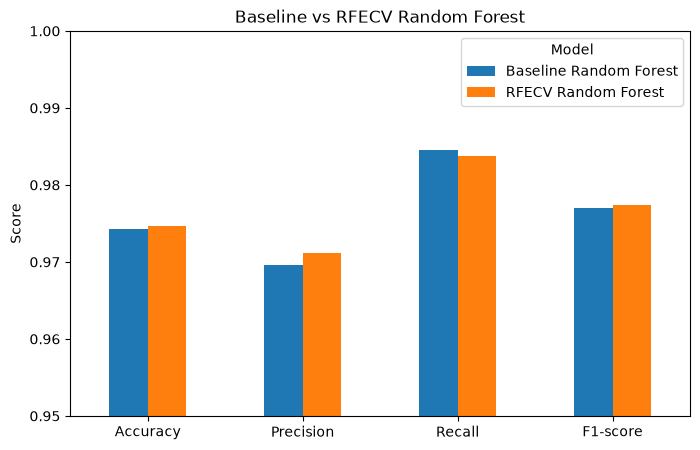

In [26]:
# Random Forest 
X = df.drop(columns=['Result'])
y = df['Result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# Baseline Random Forest
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
rf_baseline.fit(X_train, y_train)
y_pred_rf_base = rf_baseline.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_rf_base)
precision_base = precision_score(y_test, y_pred_rf_base, pos_label=1)
recall_base = recall_score(y_test, y_pred_rf_base, pos_label=1)
f1_base = f1_score(y_test, y_pred_rf_base, pos_label=1)

print("\nBaseline Random Forest")
print("----------------------")
print(f"Accuracy : {acc_base:.4f}")
print(f"Precision: {precision_base:.4f}")
print(f"Recall   : {recall_base:.4f}")
print(f"F1-score : {f1_base:.4f}")

# RFECV with Random Forest using StratifiedKFold(shuffle=True)
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rfecv_rf = RFECV(estimator=rf_selector, step=1, cv=cv_rf, scoring='accuracy', n_jobs=-1)
rfecv_rf.fit(X_train, y_train)

print("Optimal number of features (RF):", rfecv_rf.n_features_)
selected_rf = X_train.columns[rfecv_rf.support_]
print("Selected features:", list(selected_rf))

# Plot CV scores vs number of features
plt.figure(figsize=(8,5))
plt.plot(range(1, len(rfecv_rf.cv_results_['mean_test_score'])+1),
         rfecv_rf.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Number of Features')
plt.ylabel('Mean CV Accuracy')
plt.title('RFECV Performance (Random Forest)')
plt.grid(True)
plt.show()

# Transform data
X_train_rf_sel = X_train[selected_rf]
X_test_rf_sel = X_test[selected_rf]

# Train final RF with selected features
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train_rf_sel, y_train)
y_pred_rf = rf_final.predict(X_test_rf_sel)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, pos_label=1)
rec_rf = recall_score(y_test, y_pred_rf, pos_label=1)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1)

print("\nRandom Forest (RFECV Selected Features):")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Phishing (-1)', 'Legitimate (1)'],
            yticklabels=['Phishing (-1)', 'Legitimate (1)'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

#Compare Baseline Random Forest vs RFECV Random Forest
comparison = pd.DataFrame({
    'Baseline Random Forest': [
        acc_base,
        precision_base,
        recall_base,
        f1_base
    ],
    'RFECV Random Forest': [
        acc_rf,
        prec_rf,
        rec_rf,
        f1_rf
    ]
}, index=[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-score'
])

display(comparison.round(4))

comparison.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Baseline vs RFECV Random Forest')
plt.ylabel('Score')
plt.ylim(0.95, 1.00)
plt.xticks(rotation=0)
plt.legend(title='Model')

plt.show()

### Model 3 — XGBoost

In [20]:
# XGBoost
X = df.drop('Result', axis=1)
y = (df['Result'] == 1).astype(int)  # XGBoost requires labels in {0, 1}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Target distribution (train):", np.bincount(y_train))
print("Target distribution (test):", np.bincount(y_test))

# Baseline XGBoost (all features)
xgb_baseline = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_baseline.fit(X_train, y_train)
y_pred_xgb_base = xgb_baseline.predict(X_test)
print("Baseline XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb_base))

Training set: (8844, 30)
Testing set: (2211, 30)
Target distribution (train): [3918 4926]
Target distribution (test): [ 980 1231]
Baseline XGBoost Accuracy: 0.973767526006332


Optimal number of features (XGBoost): 29
Selected features: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']
Dropped features: ['on_mouseover']
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 9, 'n_estimators': 200}
Best CV Accuracy: 0.9711669552806119

XGBoost Test Performance (own RFECV-selected features):
Accuracy : 0.9765
Precision: 0.9735
Recall   : 0.9846
F1-score : 0.9790

Classification Report:
                precision    recall  f1-score   support

  Phishing (0)      

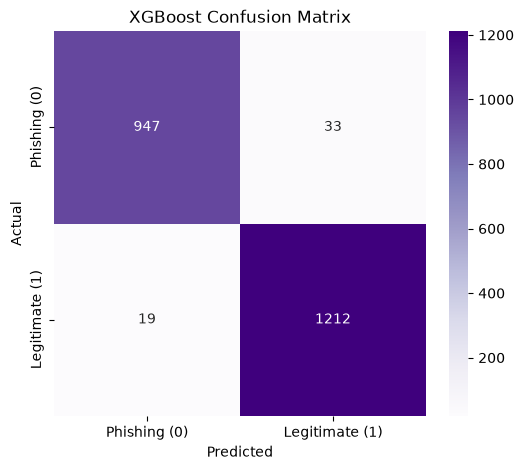

In [21]:
# XGBoost's own feature selection (RFECV with XGBoost as the estimator)

xgb_selector = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
rfecv_xgb = RFECV(estimator=xgb_selector, step=1, cv=5, scoring='accuracy', n_jobs=-1)
rfecv_xgb.fit(X_train, y_train)

print("Optimal number of features (XGBoost):", rfecv_xgb.n_features_)
selected_xgb = X_train.columns[rfecv_xgb.support_]
print("Selected features:", list(selected_xgb))
print("Dropped features:", list(X_train.columns[~rfecv_xgb.support_]))

X_train_xgb_sel = X_train[selected_xgb]
X_test_xgb_sel = X_test[selected_xgb]

# Hyperparameter tuning on XGBoost's own selected feature subset
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1)
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train_xgb_sel, y_train)

best_xgb = grid_xgb.best_estimator_
print("Best XGBoost Params:", grid_xgb.best_params_)
print("Best CV Accuracy:", grid_xgb.best_score_)

y_pred_xgb = best_xgb.predict(X_test_xgb_sel)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("\nXGBoost Test Performance (own RFECV-selected features):")
print(f"Accuracy : {acc_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall   : {rec_xgb:.4f}")
print(f"F1-score : {f1_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Phishing (0)', 'Legitimate (1)']))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Phishing (0)', 'Legitimate (1)'],
            yticklabels=['Phishing (0)', 'Legitimate (1)'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Final Model Comparison

=== Final Model Comparison ===


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.9285,0.9275,0.9482,0.9377
Random Forest,0.9747,0.9711,0.9838,0.9774
XGBoost,0.9765,0.9735,0.9846,0.9790



Best Model (based on F1-score): XGBoost with 0.9790


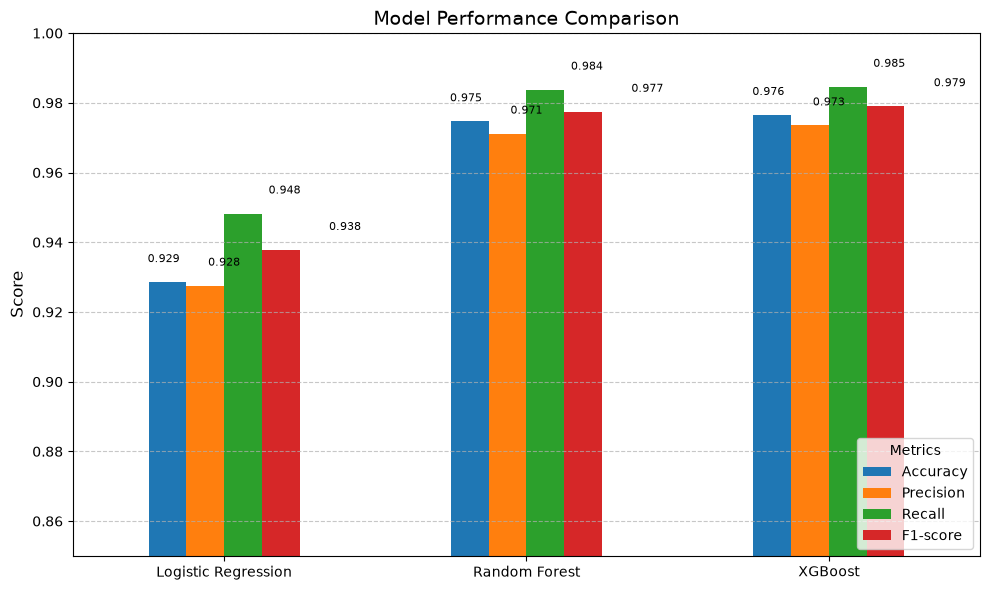

In [9]:
# Collect all results (using the best versions)
# NOTE: each model was evaluated on its own train/test split (see note above),
# so these numbers reflect each member's own methodology rather than one
# shared test set.
results = {
    'Logistic Regression': {
        'Accuracy': acc_lr_sel,
        'Precision': prec_lr_sel,
        'Recall': rec_lr_sel,
        'F1-score': f1_lr_sel
    },
    'Random Forest': {
        'Accuracy': acc_rf,
        'Precision': prec_rf,
        'Recall': rec_rf,
        'F1-score': f1_rf
    },
    'XGBoost': {
        'Accuracy': acc_xgb,
        'Precision': prec_xgb,
        'Recall': rec_xgb,
        'F1-score': f1_xgb
    }
}

comparison_df = pd.DataFrame(results).T
print("=== Final Model Comparison ===")
display(comparison_df.round(4))

# Identify best model by F1-score
best_model = comparison_df['F1-score'].idxmax()
best_f1 = comparison_df.loc[best_model, 'F1-score']
print(f"\nBest Model (based on F1-score): {best_model} with {best_f1:.4f}")

# Visual comparison
comparison_df.plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison', fontsize=14)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.85, 1.0)
plt.xticks(rotation=0)
plt.legend(title='Metrics', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, model in enumerate(comparison_df.index):
    for j, metric in enumerate(comparison_df.columns):
        val = comparison_df.iloc[i, j]
        plt.text(i - 0.2 + j*0.2, val + 0.005, f'{val:.3f}',
                 ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()